In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os.path as path
import utils
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
lau_df = utils.load_complex_geojson(path.join(utils.out_data_dir, "drought_days_lau.geojson"))
nuts3_df = utils.load_complex_geojson(path.join(utils.out_data_dir, "nuts3_stats.geojson"))
country_df = pd.read_json(path.join(utils.out_data_dir, "country_stats.geojson"))

In [3]:
# all percentages are between 0 and 100
assert((nuts3_df["cropland_area_percent"].dropna() <= 100).all())
assert((nuts3_df["cropland_area_percent"].dropna() >= 0).all())

In [4]:
# all computed drought day values must be between 0 and 365
for col in ["max_drought_days", "median_drought_days"]:
    for temp_df in [nuts3_df, lau_df]:
        assert (temp_df[col].dropna() < 365).all()
        assert (temp_df[col].dropna() >= 0).all()

In [5]:
actual_countries = list(set(nuts3_df["cntr_code"].values))
# All EU + EEA country codes and the UK. From here:
# https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Glossary:Country_codes
eea_countries = [
    "BE",
    "BG",
    "CZ",
    "DK",
    "DE",
    "EE",
    "IE",
    "EL",
    "ES",
    "FR",
    "HR",
    "IT",
    "CY",
    "LV",
    "LT",
    "LU",
    "HU",
    "MT",
    "NL",
    "AT",
    "PL",
    "PT",
    "RO",
    "SI",
    "SK",
    "FI",
    "SE",
    "IS",
    "LI",
    "NO",
    "CH",
]
assert len(eea_countries) == 30

other_countries = [
    "UK", # uk, manually added
    "RS", # slovakia, albania, north macedonia are in the NUTS and LAU dataset, despite not being in the EEA
    "AL",
    "MK",
]
expected_countries = eea_countries + other_countries

assert expected_countries == other_countries



AssertionError: 

In [ ]:
nuts3_df.dropna(subset="cropland_area_percent").sort_values(by="cropland_area_percent", ascending=False)

,nuts_id,cntr_code,name_latn,nuts_name,area_km2,population,cropland_km2,cropland_km2_by_type,cropland_area_percent,median_warning_days,max_warning_days,max_warning_days_year,median_alert_days,max_alert_days,max_alert_days_year,median_drought_days,max_drought_days,max_drought_days_year,geometry
1186,RS125,RS,Severnobačka oblast,Севернобачка област,1784.32,157170,1414.00,"{ ""Wheat"": 322.01999999999998, ""Barley"": 222.5...",79.25,26.16,181.91,2012.0,5.64,95.78,2012.0,38.25,277.69,2012.0,"POLYGON ((19.66071 46.1892, 19.68341 46.18001,..."
1164,RO312,RO,Călăraşi,Călăraşi,5078.66,278602 e,4011.83,"{ ""Wheat"": 1205.9100000000001, ""Barley"": 433.3...",78.99,32.52,234.90,2023.0,6.94,54.67,2024.0,50.91,276.35,2023.0,"POLYGON ((26.72348 44.53797, 26.75057 44.52883..."
1167,RO315,RO,Ialomiţa,Ialomiţa,4455.58,248786 e,3498.19,"{ ""Wheat"": 1034.1099999999999, ""Barley"": 265.0...",78.51,46.50,221.75,2020.0,9.37,59.38,2024.0,66.80,280.03,2020.0,"POLYGON ((26.61895 44.83328, 26.63093 44.81359..."
1169,RO317,RO,Teleorman,Teleorman,5786.99,313033 e,4358.58,"{ ""Wheat"": 1739.3699999999999, ""Barley"": 317.1...",75.32,63.76,268.37,2024.0,8.38,77.13,2012.0,92.51,344.70,2024.0,"POLYGON ((25.44462 44.46683, 25.46331 44.45907..."
549,DEG0D,DE,Sömmerda,Sömmerda,805.78,67693,589.23,"{ ""Wheat"": 216.40000000000001, ""Barley"": 129.1...",73.13,87.02,355.39,2019.0,2.95,17.19,2017.0,92.59,359.88,2019.0,"POLYGON ((11.10779 51.31099, 11.10777 51.30925..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,IS002,IS,Landsbyggð,Landsbyggð,101650.66,140390,15.19,"{ ""Fresh Vegetables"": 7.6500000000000004, ""Rap...",0.01,34.15,142.47,2019.0,2.50,9.71,2015.0,35.73,148.22,2019.0,"MULTIPOLYGON (((-16.01684 66.53358, -16.00103 ..."
1033,NO074,NO,Troms og Finnmark,Troms og Finnmark,74774.22,242452,6.37,"{ ""Barley"": 0.34000000000000002, ""Other cereal...",0.01,51.42,79.38,2014.0,4.61,10.36,2014.0,54.29,89.74,2014.0,"MULTIPOLYGON (((31.16727 70.38563, 31.16523 70..."
40,AT331,AT,Außerfern,Außerfern,1237.31,33946,0.00,{ },0.00,31.74,103.66,2018.0,1.96,16.91,2021.0,37.56,104.68,2018.0,"MULTIPOLYGON (((10.43954 47.52466, 10.45444 47..."
703,FI1D7,FI,Lappi,Lappi,98963.93,176151,1.63,"{ ""Barley"": 0.85999999999999999, ""Other cereal...",0.00,55.10,86.97,2025.0,4.53,20.64,2019.0,59.73,87.70,2025.0,"MULTIPOLYGON (((27.96056 70.08996, 27.97694 70..."


# sanity check: Top regions by agricultural percent

Severnobačka oblast - The north of Serbia is dominated by agriculture, as seen on [satellite](https://www.google.com/maps/place/Severna,+Ba%C4%8Dka+Topola,+Serbien/@45.7441886,19.5252855,65119m/data=!3m1!1e3!4m6!3m5!1s0x4744a984285dc461:0xada67651fd1d4157!8m2!3d45.8190391!4d19.6379201!16s%2Fg%2F1tdpdzmz?entry=ttu&g_ep=EgoyMDI2MDMyMy4xIKXMDSoASAFQAw%3D%3D) 

Călăraşi - is almost exclusively fielsd as confirmed visually on the areas around the city on [google maps](https://www.google.com/maps/place/C%C4%83l%C4%83ra%C8%99i,+Rum%C3%A4nien/@44.242746,27.1900369,45330m/data=!3m1!1e3!4m6!3m5!1s0x40b022bcd70432fb:0x214283a3c0ceb78d!8m2!3d44.2085144!4d27.3137439!16zL20vMDI0Xzht?entry=ttu&g_ep=EgoyMDI2MDMyMy4xIKXMDSoASAFQAw%3D%3D)

More Romanian municipalities follow, which all reflect a highly agriculturally intensive country. See below

Sömmerda in Germany makes the list with over 70% agricultural area, which also checks out when looking at [satellite data](https://www.google.com/maps/place/S%C3%B6mmerda/@51.1587729,11.1158043,11040m/data=!3m1!1e3!4m6!3m5!1s0x47a43ff535f08dd3:0x4208ec174358e70!8m2!3d51.1594582!4d11.1188764!16zL20vMDU4bG1w?entry=ttu&g_ep=EgoyMDI2MDMyMy4xIKXMDSoASAFQAw%3D%3D)

# Bottom regions by agricultural percent
Höfuðborgarsvæði - capital region of Iceland containing Reykjavik, seems plausible

Lappi - Northernmost parts of Finland are hostile to many crops

Außerfern - high up in the [austrian alps](https://www.google.com/maps/place/Reutte,+%C3%96sterreich/@47.3842441,10.5190884,20932m/data=!3m1!1e3!4m6!3m5!1s0x479cea2f08bf6609:0x40f65c3c860d7ee2!8m2!3d47.3927114!4d10.5845109!16zL20vMDZzazA4?entry=ttu&g_ep=EgoyMDI2MDMyMy4xIKXMDSoASAFQAw%3D%3D)

Troms og Finnmark - also known as Nordkap in the far north of Norway, checks out.

# General country-level cropland stats
Note: we expect our data to underestimate all cropland statistics. The High resolution layer croplands does not account for fallow lands (Brachland), which varies strongly between years. Before 2024, at least 4% of all agricultural area were required to lie fallow [as per EU rules](https://www.landwirtschaft.de/umwelt/natur/biodiversitaet/flaechenstilllegung-ausgesetzt-die-folgen-fuer-landwirtschaft-und-umwelt).

In [ ]:
# https://www.destatis.de/DE/Themen/Branchen-Unternehmen/Landwirtschaft-Forstwirtschaft-Fischerei/Feldfruechte-Gruenland/_inhalt.html#:~:text=Etwa%20die%20H%C3%A4lfte%20der%20Fl%C3%A4che%20Deutschlands%20ist,dominiert%20der%20Anbau%20von%20Getreide%20zur%20K%C3%B6rnergewinnung.
# UN stat: Cropland Area in the EU is 118810 km^2 
nuts3_df[nuts3_df["cntr_code"] == "DE"]["cropland_km2"].sum()

np.float64(112229.78)

In [ ]:
# https://statbase.org/data/rou-cropland/
# UN stat: 88130 # TODO: this discrepancy seems too high
nuts3_df[nuts3_df["cntr_code"] == "RO"]["cropland_km2"].sum()

np.float64(76041.45999999999)

In [ ]:
# https://statbase.org/data/bgr-cropland/
# UN stat: 36225
nuts3_df[nuts3_df["cntr_code"] == "BG"]["cropland_km2"].sum()

np.float64(34389.3)

# Sanity checking hotspots on the map

- Central Poland had a severe dry spell in 2019 about which a [case study](https://www.mdpi.com/2073-4433/12/11/1475) was published
- The border between CH and FR along the river Doubs is also [frequently](https://phys.org/news/2023-10-river-drought-hit-france.html) [struck](https://www.bbc.com/news/world-europe-62483293)
- Almeria and Granada in southern Spain are known [drought hotspots](https://euroweeklynews.com/2025/01/06/almeria-faces-critical-water-shortage-as-drought-deepens/)
- The 2025 spring drought in Sweden is also [reported on](https://www.lemonde.fr/en/environment/article/2025/05/25/a-spring-without-rain-northern-europe-faces-exceptional-early-drought_6741641_114.html)

# Sanity check: distribution of median and max drought days in LAUs and NUTS-3

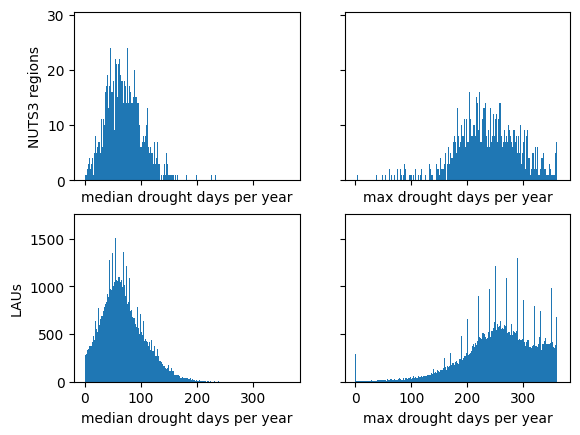

In [ ]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey="row")

for i, metric in enumerate(["median", "max"]):
    axs[0][i].hist(nuts3_df[f"{metric}_drought_days"].values, bins=365, range=(0, 366) )
    axs[0][i].set_xlabel(f"{metric} drought days per year")

    axs[1][i].hist(lau_df[f"{metric}_drought_days"].values, bins=365, range=(0, 366) )
    axs[1][i].set_xlabel(f"{metric} drought days per year")
    
axs[0][0].set_ylabel("NUTS3 regions")
axs[1][0].set_ylabel("LAUs")
plt.show()

(array([58., 23., 20., 23., 21., 15., 20., 16., 22., 16., 11., 15., 14.,
        12., 16., 22., 17., 16., 11., 21.,  8., 16., 19., 16., 11., 18.,
         8., 15., 15.,  6., 14., 13., 14., 11., 20., 10., 17., 10.,  9.,
        14., 20., 13.,  8., 17., 17.,  6., 14., 12., 11., 14., 14., 11.,
        11., 11.,  6., 11.,  9., 11., 12., 10.,  7., 12., 11., 12., 10.,
        10., 13.,  3., 13.,  8.,  7.,  6.,  5., 11.,  8., 11.,  6., 12.,
         6.,  5., 10., 13., 13.,  7.,  8.,  6.,  4.,  9.,  5., 10.,  7.,
         8.,  5.,  5.,  2.,  7.,  7.,  6.,  5.,  8.,  9.,  4.,  3.,  2.,
         5.,  2.,  5.,  5.,  0.,  4.,  6.,  3.,  3.,  3.,  4.,  5.,  2.,
         3.,  1.,  3.,  2.,  1.,  2.,  4.,  1.,  0.,  2.,  1.,  0.,  1.,
         1.,  5.,  2.,  1.,  0.,  0.,  0.,  2.,  1.,  2.,  1.,  2.,  1.,
         3.,  2.,  0.,  2.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,
         0.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.

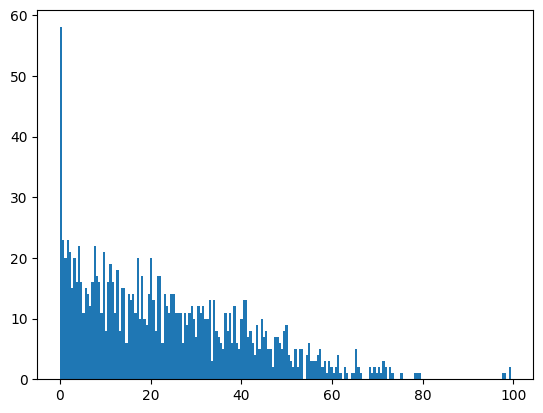

In [ ]:
plt.hist(nuts3_df["cropland_area_percent"].values, bins=200)
plt.show()